# 🚀 2강. YOLO 소개 — 실시간 객체 탐지 모델

> 📌 **이 노트북의 목표**
> - CLI와 Python API 양쪽으로 YOLO를 직접 돌려본다.
> - 탐지(Detect) 외에 포즈 추정(Pose)까지 같은 사진에 적용해 "태스크만 바꾸면 된다"는 감각을 잡는다.
> - 배포(ONNX 내보내기)와 커스텀 학습(train)까지 한 번씩 실제로 실행해 전체 라이프사이클을 손으로 만져본다.

**공식 저장소**
- [ultralytics/ultralytics](https://github.com/ultralytics/ultralytics) — YOLO 모델·학습·추론 전부 이 저장소 하나
- [공식 문서](https://docs.ultralytics.com/) · [CLI 문서](https://docs.ultralytics.com/usage/cli) · [Python 문서](https://docs.ultralytics.com/usage/python)
- 이 노트북은 워크샵 전체와 일관성을 맞추기 위해 **YOLO11**을 씁니다. 2026년 현재 공식 README의 기본 예시는
  더 최신 세대인 [YOLO26](https://docs.ultralytics.com/models/yolo26)이지만(같은 `ultralytics` 패키지로 `yolo26n.pt`만
  바꿔 끼우면 그대로 동작), 이 워크샵의 다른 프로젝트(`yolo1_rps`, `yolo3_recycling`)가 전부 YOLO11로 학습·검증되어
  있어 통일성을 위해 유지합니다.

## 목차
1. 설치
2. 기본 작동 방법 — CLI · Python API · 다른 태스크(Pose) · 내보내기 · 학습
3. 특징 정리
4. 🤝 AI Pair 섹션


## 1. 설치

`ultralytics` 패키지 하나로 CLI(`yolo` 명령)와 Python API를 전부 씁니다. PyTorch가 함께 설치됩니다.


In [1]:
%pip install -q ultralytics


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import ultralytics
import torch

print("ultralytics 버전:", ultralytics.__version__)
print("torch 버전:", torch.__version__)
print("GPU 가속 사용 가능?", "CUDA" if torch.cuda.is_available() else ("MPS(Apple Silicon)" if torch.backends.mps.is_available() else "CPU만 가능"))


ultralytics 버전: 8.4.113
torch 버전: 2.13.0
GPU 가속 사용 가능? MPS(Apple Silicon)


버전과 GPU 가속 여부를 항상 먼저 확인하는 습관을 들이세요 — 같은 코드도 CPU/MPS/CUDA에 따라
속도가 크게 다르고, 버전에 따라 API가 바뀌기도 합니다.

## 2. 기본 작동 방법

### 2.1 CLI(명령줄)로 먼저 감 잡기

Python 코드를 한 줄도 안 쓰고 터미널에서 바로 추론해 볼 수 있습니다 — 프로토타이핑에 가장 빠른 방법입니다.

```bash
yolo predict model=yolo11n.pt source='https://ultralytics.com/images/bus.jpg'
```

이 노트북에서는 아래 셀로 같은 명령을 실행합니다(`!`는 Jupyter에서 셸 명령을 실행하는 표기).


In [ ]:
!yolo predict model=yolo11n.pt source='https://ultralytics.com/images/bus.jpg'




Ultralytics 8.4.113 🚀 Python-3.11.15 torch-2.13.0 CPU (Apple M3 Pro)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /Users/sanguinekim/Documents/3_Code/Vibe/Project/260728_vision_vibe_workshop/lecture/bus.jpg: 640x480 4 persons, 1 bus, 85.6ms
Speed: 4.8ms preprocess, 85.6ms inference, 7.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /Users/sanguinekim/Documents/3_Code/Vibe/Project/runs/detect/predict-5
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [4]:
!yolo predict model=yolo11n.pt source=https://imgnews.pstatic.net/image/658/2026/07/30/0000150960_001_20260730082619631.jpg

Ultralytics 8.4.113 🚀 Python-3.11.15 torch-2.13.0 CPU (Apple M3 Pro)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /Users/sanguinekim/Documents/3_Code/Vibe/Project/260728_vision_vibe_workshop/lecture/0000150960_001_20260730082619631.jpg: 448x640 1 person, 1 tie, 237.0ms
Speed: 2.3ms preprocess, 237.0ms inference, 3.2ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /Users/sanguinekim/Documents/3_Code/Vibe/Project/runs/detect/predict-6
💡 Learn more at https://docs.ultralytics.com/modes/predict


`yolo` 명령은 `predict` 외에 `train`(학습) · `val`(검증) · `export`(내보내기) 모드를 지원합니다.
`imgsz=640`, `conf=0.5`, `device=cpu` 처럼 인자를 이어붙이면 됩니다. 전체 옵션은
[CLI 문서](https://docs.ultralytics.com/usage/cli)에 정리되어 있습니다.

### 2.2 Python API — 모델 로드


In [5]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")  # n = nano, 가장 가볍고 빠른 버전
print("불러온 태스크:", model.task)   # detect / segment / classify / pose / obb 중 하나
print("클래스 개수:", len(model.names))
print("클래스 예시:", list(model.names.values())[:10], "...")


불러온 태스크: detect
클래스 개수: 80
클래스 예시: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light'] ...


### 2.3 추론 실행


In [6]:
result = model("https://ultralytics.com/images/bus.jpg")
r = result[0]  # 이미지 1장이라도 결과는 항상 리스트로 온다 (배치 추론 대비)
print(f"\n검출된 객체 수: {len(r.boxes)}")



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /Users/sanguinekim/Documents/3_Code/Vibe/Project/260728_vision_vibe_workshop/lecture/bus.jpg: 640x480 4 persons, 1 bus, 146.4ms
Speed: 5.4ms preprocess, 146.4ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 480)

검출된 객체 수: 5


### 2.4 결과 해석

각 검출 결과는 **박스 좌표(box) · 클래스(class) · 신뢰도(confidence)** 세 가지로 구성됩니다.


In [6]:
for box in r.boxes:
    cls_id = int(box.cls[0])
    class_name = model.names[cls_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    print(f"{class_name:10s} 신뢰도={confidence:.2f}  박스=({x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f})")


bus        신뢰도=0.94  박스=(4, 229, 796, 728)
person     신뢰도=0.89  박스=(671, 395, 810, 879)
person     신뢰도=0.88  박스=(47, 400, 239, 904)
person     신뢰도=0.86  박스=(223, 409, 344, 860)
person     신뢰도=0.62  박스=(0, 556, 69, 872)


### 2.5 시각화

`.plot()`을 호출하면 박스·클래스명·신뢰도가 그려진 이미지를 바로 얻습니다.


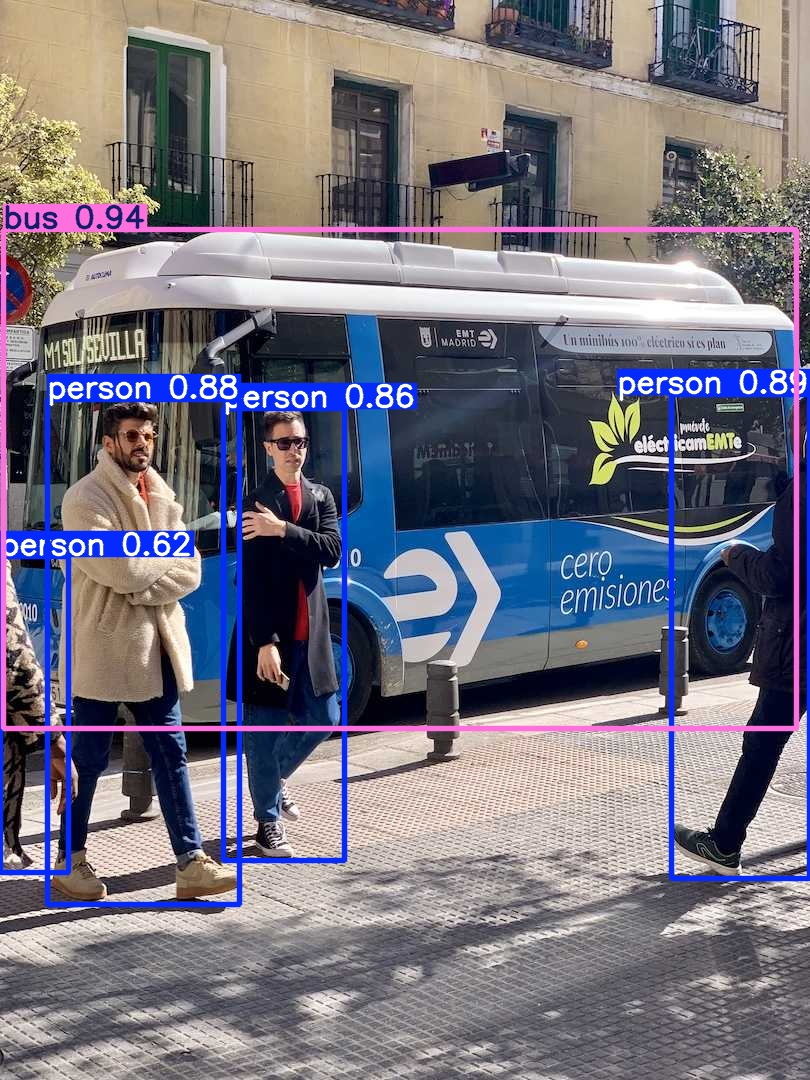

In [7]:
import cv2
from IPython.display import Image, display

annotated = r.plot()  # BGR numpy 배열, 박스·라벨이 이미 그려져 있음
cv2.imwrite("yolo_result.jpg", annotated)
display(Image(filename="yolo_result.jpg"))


### 2.6 다른 태스크로 바꿔보기 — 같은 사진, 포즈 추정(Pose)

모델 파일 접미사만 바꾸면 완전히 다른 태스크가 됩니다. 방금 쓴 `yolo11n.pt`(탐지) 대신
`yolo11n-pose.pt`를 로드하면 같은 사진에서 **사람마다 17개 관절 좌표**를 뽑아냅니다 — 코드 구조는
동일하고 모델과 결과 필드(`.keypoints`)만 다릅니다.


포즈 검출된 사람 수: 4
키포인트 shape: (4, 17, 2) ← (사람 수, 17개 관절, x/y)


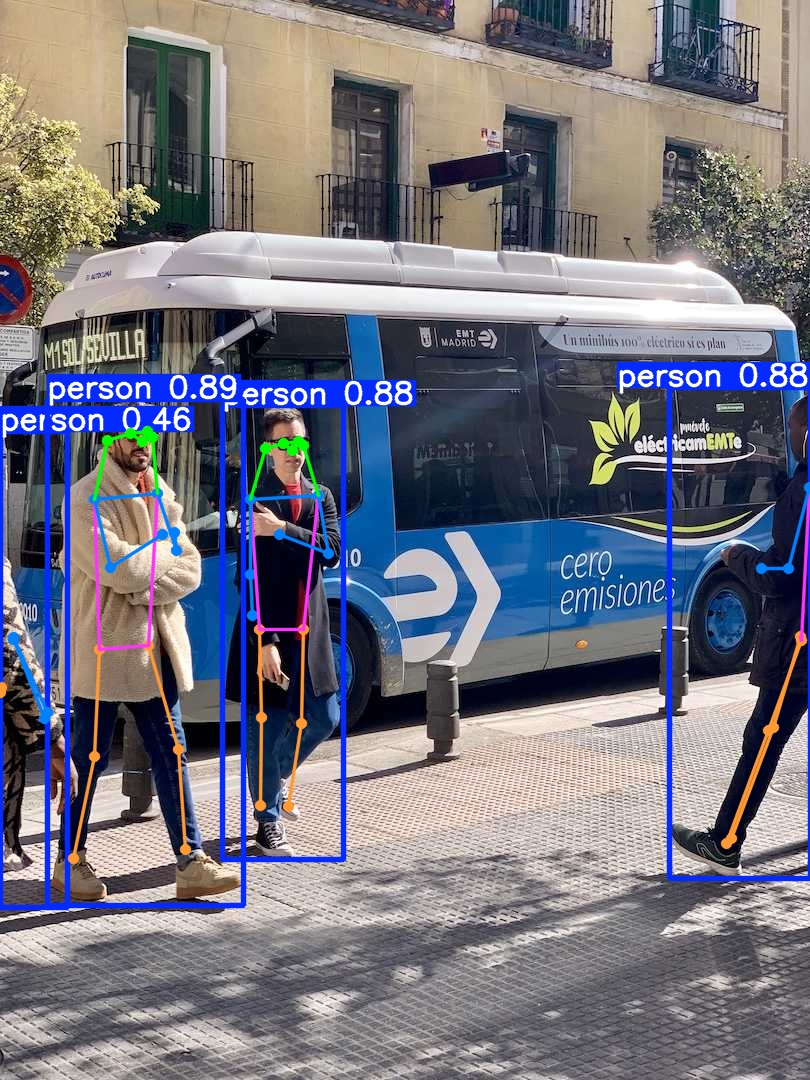

In [8]:
pose_model = YOLO("yolo11n-pose.pt")
pose_result = pose_model("bus.jpg", verbose=False)
pr = pose_result[0]

print("포즈 검출된 사람 수:", len(pr.keypoints))
print("키포인트 shape:", tuple(pr.keypoints.xy.shape), "← (사람 수, 17개 관절, x/y)")

pose_annotated = pr.plot()
cv2.imwrite("pose_result.jpg", pose_annotated)
display(Image(filename="pose_result.jpg"))


> `.boxes`(탐지) → `.keypoints`(포즈)만 바뀌었을 뿐, `model = YOLO(...)` → `model(이미지)` → `.plot()`
> 흐름은 동일합니다. `yolo11n-seg.pt`(분할)·`yolo11n-cls.pt`(분류)·`yolo11n-obb.pt`(회전박스)도 같은 패턴입니다.

### 2.7 모델 내보내기(Export) — 배포 준비

학습·실험은 PyTorch(`.pt`)로 하지만, 실제 배포(웹·모바일·임베디드)에는 더 가볍고 이식성 높은 포맷으로
바꿉니다. `export()` 한 줄로 변환됩니다.


In [9]:
onnx_path = model.export(format="onnx")  # PyTorch → ONNX(범용 추론 포맷)로 변환
import os
print("ONNX 내보내기 완료:", onnx_path)
print("파일 크기:", round(os.path.getsize(onnx_path) / 1_000_000, 1), "MB (원본 .pt는 5.4MB)")


Ultralytics 8.4.113 🚀 Python-3.11.15 torch-2.13.0 CPU (Apple M3 Pro)



PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)



ONNX: starting export with onnx 1.22.0 opset 20...


ONNX: slimming with onnxslim 0.1.94...


ONNX: export success ✅ 0.8s, saved as 'yolo11n.onnx' (10.2 MB)



Export complete (0.9s)
Results saved to /Users/sanguinekim/Documents/3_Code/Vibe/Project/260728_vision_vibe_workshop/lecture/yolo11n.onnx
Predict:         yolo predict task=detect model=yolo11n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolo11n.onnx imgsz=640 data=/usr/src/ultralytics/ultralytics/cfg/datasets/coco.yaml  
Visualize:       https://netron.app


ONNX 내보내기 완료: yolo11n.onnx
파일 크기: 10.7 MB (원본 .pt는 5.4MB)


ONNX가 원본보다 오히려 커진 이유는 **연산 그래프를 자체 완결적으로(가중치+구조 전부) 담기 때문**입니다.
대신 PyTorch 런타임 없이도(ONNX Runtime, TensorRT, OpenVINO 등에서) 돌릴 수 있어 배포 환경 선택이 자유로워집니다.
지원 포맷 전체 목록은 [Export 문서](https://docs.ultralytics.com/modes/export)에 있습니다(TensorRT·CoreML·TFLite 등).

### 2.8 커스텀 데이터로 학습(Train) — 라이프사이클의 마지막 조각

지금까지는 COCO로 사전학습된 모델을 그대로 썼습니다. 내 도메인 대상(이 워크샵의 가위바위보·번호판처럼)은
직접 학습시켜야 합니다. 공식 튜토리얼 데이터셋인 **COCO8**(이미지 8장짜리 초소형 세트, 코드 동작 확인용)로
학습 API 자체를 확인해 봅니다 — 실제 프로젝트에서는 `epochs=50~100`, 이미지 수백~수천 장을 씁니다.


### 3.5 사전학습 vs 커스텀 학습

범용 대상(사람·차·동물)은 COCO 사전학습 모델을 그대로 씁니다. 번호판·특정 제품처럼 **내 도메인에만
있는 대상**은 `model.train(data=..., epochs=...)`으로 직접 학습(또는 파인튜닝)해야 합니다 — 이번에
COCO8로 실행해 본 바로 그 API입니다.

### 3.6 실전 활용 사례 — 자율주행에도 쓸 수 있을까?

**결론부터: 쓸 수 있는 계열이 맞지만, "그대로 갖다 쓰면 자율주행이 된다"는 아닙니다.**

- YOLO의 핵심 강점(실시간성, 한 번의 순전파로 위치+클래스 동시 예측)은 자율주행처럼 밀리초 단위
  지연시간 제약이 있는 도메인에 정확히 맞습니다. 실제로 차량·보행자·자전거·표지판 탐지 같은
  ADAS(첨단 운전자 보조) 연구·프로토타입에서 YOLO 계열이 널리 쓰입니다.
- 하지만 3.5절에서 본 것처럼 COCO 사전학습 모델은 범용 80종만 압니다 — 자율주행에는
  KITTI·nuScenes·Waymo Open Dataset 같은 도메인 특화 데이터로 `model.train()`을 다시 돌려야 합니다.
- 진짜 양산 자율주행 스택(Tesla, Waymo 등)은 카메라 2D 탐지만으로 끝나지 않습니다 — LiDAR/레이더
  센서 퓨전, 3D 바운딩박스, ISO 26262 같은 기능안전 인증까지 필요해서, YOLO를 인식 파이프라인의
  한 구성요소로 쓰거나 자체 모델로 완전히 대체하는 경우가 많습니다.

즉 "실시간 2D 객체 탐지"라는 문제 자체엔 YOLO가 아주 적합한 선택지이지만, 자율주행 전체 인식
스택의 일부일 뿐 그 자체로 자율주행 솔루션은 아닙니다.

## 4. 🤝 AI Pair 섹션 — YOLO 코드, AI와 함께 검증하기

### 1️⃣ Solo — 직접 작성해 보세요

`bus.jpg`에 `yolo11n-cls.pt`(분류 모델)를 로드해 돌려보세요. 탐지와 달리 분류는 박스가 없고
`result[0].probs.top1`(가장 높은 확률의 클래스 인덱스)과 `result[0].probs.top1conf`(그 확률)를 씁니다.

1 에폭·8장짜리 장난감 학습이라 mAP 수치 자체는 의미가 없습니다 — 여기서 확인할 건 **API가 실제로
동작한다는 것**뿐입니다. Part 1(가위바위보)·Part 2(번호판)·`yolo3_recycling`(재활용 분류)이 전부 이
`model.train(data=..., epochs=...)` 한 줄에서 시작했습니다.

> **겪은 함정**: 위 2.7절에서 `export()`한 그 `model` 객체를 그대로 이어서 학습시켰더니 mAP50이
> 0.649에서 0.005로 폭락했습니다 — `export()`가 추론 최적화를 위해 레이어를 fuse(합성)해 버려서,
> 학습에 필요한 원래 가중치 구조("Transferred 499/499 items"가 아니라 겨우 94/499)를 잃었기
> 때문입니다. **내보내기(export)와 학습(train)은 항상 별도의 모델 인스턴스로 하세요.**

## 3. 특징 정리

### 3.1 왜 "You Only Look Once"인가
2단계 탐지기(R-CNN 계열)는 "① 후보 영역을 먼저 찾고 → ② 각 영역을 따로 분류"하는 2번의 패스를 거칩니다.
YOLO는 이미지 전체를 신경망에 **한 번만** 통과시켜 위치와 클래스를 동시에 예측합니다.

### 3.2 지원하는 태스크

| 태스크 | 접미사 예시 | 하는 일 |
|---|---|---|
| Detect(탐지) | `yolo11n.pt` | 물체의 위치(박스)와 종류 |
| Segment(분할) | `yolo11n-seg.pt` | 물체의 정확한 윤곽(픽셀 단위) |
| Classify(분류) | `yolo11n-cls.pt` | 이미지 전체를 하나로 분류 |
| Pose(자세 추정) | `yolo11n-pose.pt` | 사람 관절 keypoint — 이번에 직접 실행함 |
| OBB(회전 박스) | `yolo11n-obb.pt` | 항공사진처럼 기울어진 물체 |

[전체 태스크 문서](https://docs.ultralytics.com/tasks)

### 3.3 모델 크기 트레이드오프 — n/s/m/l/x

| 크기 | 특징 |
|---|---|
| n (nano) | 가장 가볍고 빠름 — 모바일·엣지, 실시간성 최우선 |
| s (small) | 저사양 환경에서 정확도를 조금 더 |
| m (medium) | 속도-정확도 균형 |
| l (large) | 정확도 우선 — 서버 배치 처리 |
| x (extra-large) | 최고 정확도 |

### 3.4 최신 세대 — YOLO26

이 노트북은 워크샵 통일성을 위해 YOLO11을 썼지만, 2026년 현재 [ultralytics 공식 저장소](https://github.com/ultralytics/ultralytics)의
기본 예시는 **YOLO26**입니다. 같은 코드에서 `"yolo11n.pt"` → `"yolo26n.pt"`로만 바꾸면 그대로 동작합니다
— API가 아니라 가중치 파일만 바뀝니다.

### 3.5 사전학습 vs 커스텀 학습

범용 대상(사람·차·동물)은 COCO 사전학습 모델을 그대로 씁니다. 번호판·특정 제품처럼 **내 도메인에만
있는 대상**은 `model.train(data=..., epochs=...)`으로 직접 학습(또는 파인튜닝)해야 합니다 — 이번에
COCO8로 실행해 본 바로 그 API입니다.

## 4. 🤝 AI Pair 섹션 — YOLO 코드, AI와 함께 검증하기

### 1️⃣ Solo — 직접 작성해 보세요

`bus.jpg`에 `yolo11n-cls.pt`(분류 모델)를 로드해 돌려보세요. 탐지와 달리 분류는 박스가 없고
`result[0].probs.top1`(가장 높은 확률의 클래스 인덱스)과 `result[0].probs.top1conf`(그 확률)를 씁니다.


In [11]:
# [Solo] 여기에 yolo11n-cls.pt로 분류를 실행하는 코드를 작성해 보세요.
# 힌트: cls_model = YOLO("yolo11n-cls.pt")
#      cls_result = cls_model("bus.jpg")
#      top1 = cls_result[0].probs.top1
#      print(cls_model.names[top1], cls_result[0].probs.top1conf.item())


### 2️⃣ Review

아래 프롬프트를 복사해 ChatGPT/Claude에 붙여넣으세요.

```text
YOLO로 커스텀 객체(예: 우리 회사 제품 로고)를 탐지하고 싶습니다. COCO 사전학습 모델(yolo11n.pt)을
그대로 쓰면 안 되는 이유와, model.train(data="내데이터.yaml", epochs=50)을 실행하기 전에 준비해야
할 데이터셋 형식(이미지+라벨 폴더 구조, yaml 작성법)을 설명해주세요.
```

### 3️⃣ Debug — "조용히 틀린" 코드 찾기

아래는 **실행은 되고 에러도 안 나지만, 조용히 잘못된 정보를 주는** 코드입니다. 결함을 찾아 고치세요.


In [12]:
# [Debug] 아래 코드는 에러 없이 실행됩니다 — 그런데 항상 "검출 없음"만 나옵니다. 결함을 찾아 고쳐보세요.
buggy_model = YOLO("yolo11n.pt")
buggy_result = buggy_model("bus.jpg", conf=0.99)   # <- 여기가 의심 지점
print("검출 개수:", len(buggy_result[0].boxes))


image 1/1 /Users/sanguinekim/Documents/3_Code/Vibe/Project/260728_vision_vibe_workshop/lecture/bus.jpg: 640x480 (no detections), 32.6ms


Speed: 1.2ms preprocess, 32.6ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 480)


검출 개수: 0


💭 **생각해 볼 점**:
- `conf=0.99`는 "신뢰도 99% 이상만 인정"하겠다는 뜻입니다. 실제 탐지 결과의 최고 신뢰도는 0.94(버스)였으니
  전부 기준 미달로 걸러집니다.
- 왜 에러가 안 날까요? "검출 결과 0개"는 정상적인 반환값(빈 리스트)이지 예외 상황이 아니기 때문입니다 —
  실행은 성공했는데 조건이 너무 엄격했을 뿐입니다.
- 고치는 법: `conf` 기본값(0.25~0.5권)으로 되돌리거나, 왜 이 임계값을 0.99로 뒀는지부터 재검토합니다.

### 4️⃣ Prompt Card

```text
1. "YOLO11n(2.6M 파라미터)과 YOLO11x(56.9M 파라미터)를 같은 사진에 돌리면 속도·정확도가 어떻게
   달라질지" 먼저 예측한 뒤 AI에게 근거를 물어 검증하세요.
2. "model.export(format='onnx')와 format='tflite'의 차이"를 AI에게 설명받고, 각각 어떤 배포
   환경(서버/모바일)에 적합한지 확인해보세요.
3. "YOLO의 conf(신뢰도 임계값)와 iou(NMS 임계값) 파라미터가 각각 무엇을 제어하는지"를 AI에게 물어보고,
   두 값을 낮췄을 때 검출 개수가 각각 왜 다른 방향으로 바뀌는지 실험해보세요.
```

---
## 📚 [세션 요약] YOLO 소개

> 🎯 **핵심 Takeaways**
> 1. **이론적 근거**: 이미지를 한 번만 통과시켜(You Only Look Once) 위치·클래스를 동시에 예측 — 2단계 탐지기보다 빠르다.
> 2. **실무적 활용**: CLI(`yolo predict`)로 빠르게 찔러보고, Python API로 파이프라인에 통합하고, `export()`로 배포 포맷을 바꾼다. 태스크(탐지/포즈/분할/분류)는 모델 파일만 바꾸면 전환된다.
> 3. **한계와 대응**: 사전학습 모델은 COCO 80종 밖의 대상을 모른다 — `model.train()`으로 직접 학습해야 하고, 그 실측 결과는 1강(OpenCV)만큼 예측 가능하지 않다(4강에서 확신도 높은 오분류 사례 확인).
> 4. **다음 강의 예고**: 3강에서는 "학습 없이 구글이 이미 학습해 둔 모델을 그대로 쓰는" MediaPipe를 다룹니다.
